# Day 10 — Building a Neural Network from Scratch

The goal of this experiment is to understand what actually happens inside a
small neural network instead of relying completely on a deep learning library.

I will build a two-layer neural network using NumPy and implement the forward
pass, backpropagation, and gradient descent manually.

After that, I will train scikit-learn's MLPClassifier on exactly the same
training and testing data and compare the results.

In [4]:
# imports

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, log_loss

In [5]:
# create the dataset

X, y = make_moons(
    n_samples=1000,
    noise=0.20,
    random_state=42
)

print("X:", X.shape)
print("y:", y.shape)

X: (1000, 2)
y: (1000,)


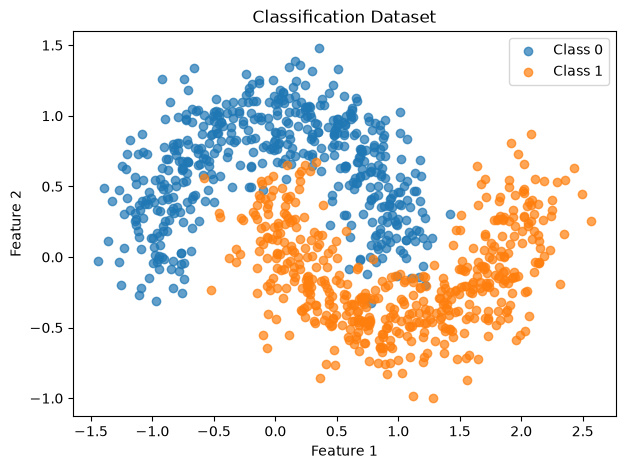

In [6]:
# quick look at the data

plt.figure(figsize=(7, 5))

plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0", alpha=0.7)
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1", alpha=0.7)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Classification Dataset")
plt.legend()
plt.show()

In [7]:
# split and scale

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape)
print("Test :", X_test_scaled.shape)

Train: (800, 2)
Test : (200, 2)


In [8]:
# network setup

input_size = X_train_scaled.shape[1]
hidden_size = 16
output_size = 1

learning_rate = 0.05
epochs = 3000

np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size)
b2 = np.zeros((1, output_size))

print(W1.shape, W2.shape)

(2, 16) (16, 1)


In [9]:
# activation functions

def relu(x):
    return np.maximum(0, x)


def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

In [10]:
# forward pass

def forward_pass(X):
    z1 = X @ W1 + b1
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)

    return z1, a1, z2, a2

In [11]:
# loss

def binary_cross_entropy(y_true, y_pred):
    y_true = y_true.reshape(-1, 1)

    y_pred = np.clip(
        y_pred,
        1e-9,
        1 - 1e-9
    )

    return -np.mean(
        y_true * np.log(y_pred)
        + (1 - y_true) * np.log(1 - y_pred)
    )

In [12]:
# backpropagation

def backward_pass(X, y, z1, a1, a2):
    y = y.reshape(-1, 1)
    n = X.shape[0]

    dz2 = a2 - y

    dW2 = (a1.T @ dz2) / n
    db2 = np.sum(dz2, axis=0, keepdims=True) / n

    da1 = dz2 @ W2.T
    dz1 = da1 * (z1 > 0)

    dW1 = (X.T @ dz1) / n
    db1 = np.sum(dz1, axis=0, keepdims=True) / n

    return dW1, db1, dW2, db2

In [13]:
# train from scratch

loss_history = []

start_time = time.perf_counter()

for epoch in range(epochs):

    z1, a1, z2, a2 = forward_pass(X_train_scaled)

    loss = binary_cross_entropy(y_train, a2)

    dW1, db1, dW2, db2 = backward_pass(
        X_train_scaled,
        y_train,
        z1,
        a1,
        a2
    )

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    loss_history.append(loss)

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss:.4f}")

numpy_training_time = time.perf_counter() - start_time

print("Training time:", round(numpy_training_time, 3), "seconds")

Epoch 500/3000 - Loss: 0.2849
Epoch 1000/3000 - Loss: 0.2512
Epoch 1500/3000 - Loss: 0.2084
Epoch 2000/3000 - Loss: 0.1683
Epoch 2500/3000 - Loss: 0.1378
Epoch 3000/3000 - Loss: 0.1177
Training time: 0.357 seconds


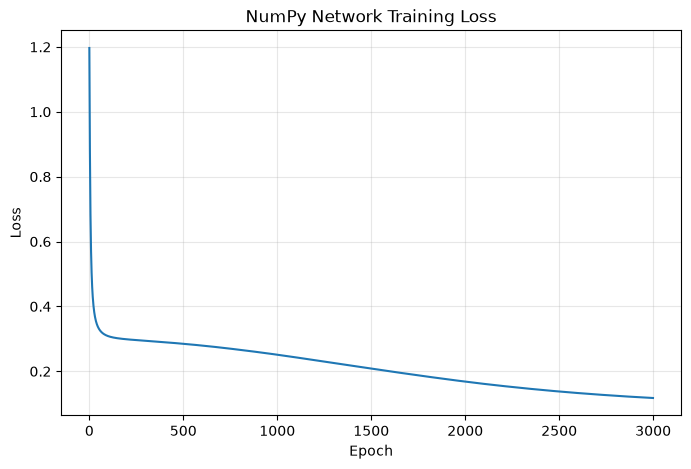

In [14]:
# check training loss

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("NumPy Network Training Loss")
plt.grid(alpha=0.3)

plt.show()

In [15]:
# evaluate the NumPy model

_, _, _, numpy_prob = forward_pass(X_test_scaled)

numpy_pred = (numpy_prob.ravel() >= 0.5).astype(int)

numpy_accuracy = accuracy_score(y_test, numpy_pred)
numpy_logloss = log_loss(y_test, numpy_prob.ravel())

print("NumPy model")
print("Accuracy:", round(numpy_accuracy, 4))
print("Log loss:", round(numpy_logloss, 4))

NumPy model
Accuracy: 0.975
Log loss: 0.0825


In [16]:
# classification report

print(
    classification_report(
        y_test,
        numpy_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9798    0.9700    0.9749       100
           1     0.9703    0.9800    0.9751       100

    accuracy                         0.9750       200
   macro avg     0.9750    0.9750    0.9750       200
weighted avg     0.9750    0.9750    0.9750       200



In [17]:
# sklearn MLP baseline

sklearn_mlp = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation="relu",
    solver="adam",
    learning_rate_init=0.05,
    max_iter=3000,
    random_state=42
)

start_time = time.perf_counter()

sklearn_mlp.fit(
    X_train_scaled,
    y_train
)

sklearn_training_time = time.perf_counter() - start_time

print(
    "sklearn training time:",
    round(sklearn_training_time, 3),
    "seconds"
)

sklearn training time: 0.1 seconds


In [18]:
# evaluate sklearn model

sklearn_pred = sklearn_mlp.predict(X_test_scaled)

sklearn_prob = sklearn_mlp.predict_proba(
    X_test_scaled
)[:, 1]

sklearn_accuracy = accuracy_score(
    y_test,
    sklearn_pred
)

sklearn_logloss = log_loss(
    y_test,
    sklearn_prob
)

print("sklearn MLP")
print("Accuracy:", round(sklearn_accuracy, 4))
print("Log loss:", round(sklearn_logloss, 4))

sklearn MLP
Accuracy: 0.995
Log loss: 0.0297


In [19]:
# compare both models

comparison = pd.DataFrame({
    "Model": [
        "NumPy Neural Network",
        "sklearn MLPClassifier"
    ],
    "Accuracy": [
        numpy_accuracy,
        sklearn_accuracy
    ],
    "Log Loss": [
        numpy_logloss,
        sklearn_logloss
    ],
    "Training Time (s)": [
        numpy_training_time,
        sklearn_training_time
    ]
})

comparison

,Model,Accuracy,Log Loss,Training Time (s)
0,NumPy Neural Network,0.975,0.082528,0.357311
1,sklearn MLPClassifier,0.995,0.029714,0.100435


In [20]:
# check prediction agreement

agreement = np.mean(
    numpy_pred == sklearn_pred
)

print(
    "Prediction agreement:",
    round(agreement, 4)
)

print(
    "Different predictions:",
    np.sum(numpy_pred != sklearn_pred)
)

Prediction agreement: 0.98
Different predictions: 4


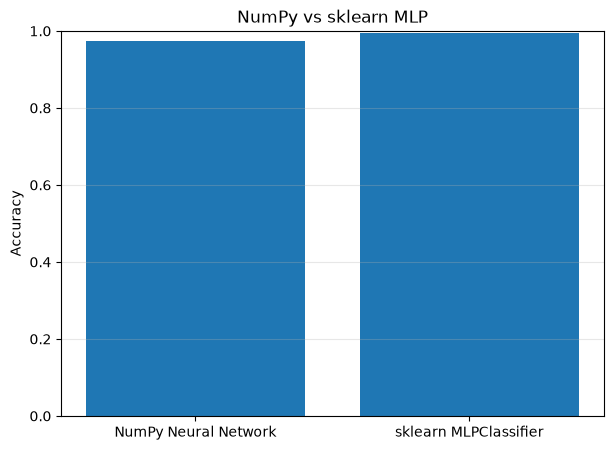

In [21]:
# final comparison plot

plt.figure(figsize=(7, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("NumPy vs sklearn MLP")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [22]:
# final result

print("=" * 50)
print("DAY 10 RESULTS")
print("=" * 50)

print(
    f"NumPy NN accuracy : {numpy_accuracy:.4f}"
)

print(
    f"sklearn accuracy  : {sklearn_accuracy:.4f}"
)

print(
    f"Prediction agreement : {agreement:.2%}"
)

print("\nThe NumPy model successfully learned the classification task.")
print("The sklearn MLP was used as a reference implementation.")

DAY 10 RESULTS
NumPy NN accuracy : 0.9750
sklearn accuracy  : 0.9950
Prediction agreement : 98.00%

The NumPy model successfully learned the classification task.
The sklearn MLP was used as a reference implementation.
